##### Now, let's look at employment / unemployment

First, we need to clarify the definition: employment rate means the part of the population, which is employed (having a job) - no surprise

But *un*employment is much more interesting: Is does not simply refer to the opposite group of people, but rather people, who are without work, currently available and *actively seeking work* - meaning, people, who have already given up on searching and e.g. retired early, do not count into the definition.

For data, we use worldbank.org and national estimates

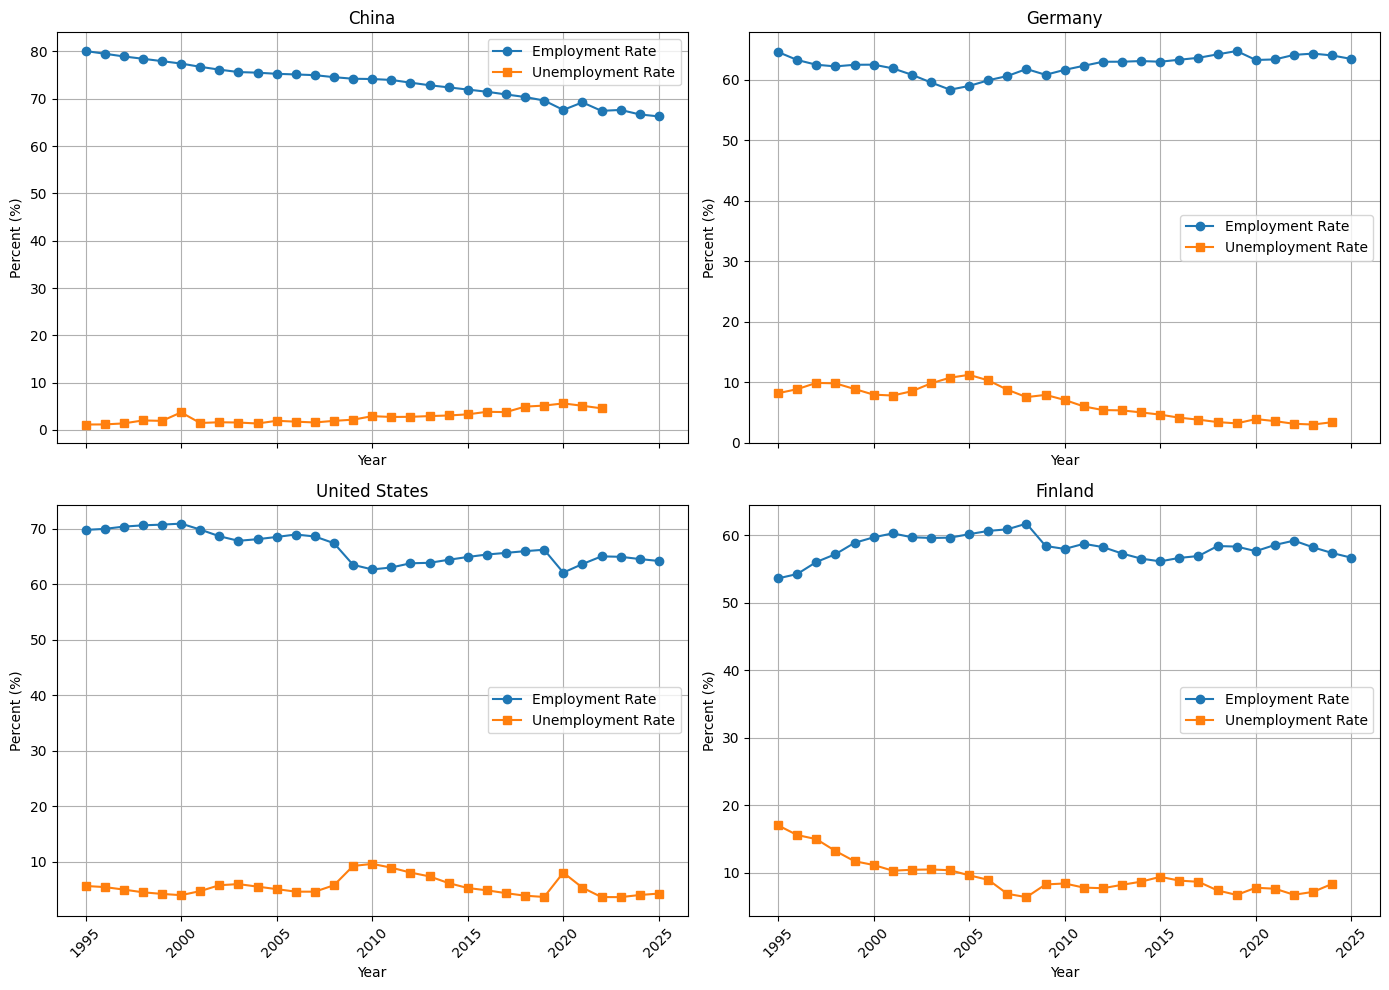

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# File paths
emp_path = 'data/un_employment_data/API_SL.EMP.TOTL.SP.MA.ZS_DS2_en_csv_v2_10149.csv'
uem_path = 'data/un_employment_data/API_SL.UEM.TOTL.NE.ZS_DS2_en_csv_v2_2004.csv'

# Countries and years
countries = ['China', 'Germany', 'United States', 'Finland']
years = [str(y) for y in range(1995, 2026)]

# Helper to load and extract data for a set of countries
def extract_country_data(filepath, value_name):
    df = pd.read_csv(filepath, skiprows=4)
    df = df[df['Country Name'].isin(countries)]
    df = df[['Country Name'] + years]
    df = df.set_index('Country Name').T
    df.index.name = 'Year'
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.reset_index().melt(id_vars='Year', var_name='Country', value_name=value_name)
    return df

# Load data
emp_df = extract_country_data(emp_path, 'Employment Rate')
uem_df = extract_country_data(uem_path, 'Unemployment Rate')

# Merge data
merged = pd.merge(emp_df, uem_df, on=['Year', 'Country'], how='outer')

# Plot
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axs = axs.flatten()
for i, country in enumerate(countries):
    data = merged[merged['Country'] == country]
    ax = axs[i]
    ax.plot(data['Year'], data['Employment Rate'], label='Employment Rate', marker='o')
    ax.plot(data['Year'], data['Unemployment Rate'], label='Unemployment Rate', marker='s')
    ax.set_title(country)
    ax.set_xlabel('Year')
    ax.set_ylabel('Percent (%)')
    ax.legend()
    ax.grid(True)
    # Set x-ticks every 5 years
    xticks = [str(y) for y in range(1995, 2026, 5)]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, rotation=45)
plt.tight_layout()
plt.show()
